In [2]:
import os
print("Current working directory:", os.getcwd())

Current working directory: d:\Projekty\Python\Magisterka\notebooks


# 1 pomiar

Wczytanie pomiarów

In [3]:
import pandas as pd
import os
import csv
from io import StringIO

# Get the notebook's directory and go up to the project root
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Go up from notebooks/ to project root
path = os.path.join(project_root, "data", "17.09.2025_03")

print(f"Data path: {path}")  # Debug: show the actual path being used

head = "Date,id,Tx_p,rssi\n"

with open(os.path.join(path, "0.5m_100.txt"), "r") as f:
    content = f.read()
    d05m = pd.read_csv(StringIO(head+content))
   
with open(os.path.join(path, "1.0m_100.txt"), "r") as f:
    content = f.read()
    d1m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "2.0m_100.txt"), "r") as f:
    content = f.read()
    d2m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "3.0m_100.txt"), "r") as f:
    content = f.read()
    d3m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "5.0m_100.txt"), "r") as f:
    content = f.read()
    d5m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "7.0m_100.txt"), "r") as f:
    content = f.read()
    d7m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "10.0m_100.txt"), "r") as f:
    content = f.read()
    d10m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "13.0m_100.txt"), "r") as f:
    content = f.read()
    d13m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "15.0m_100.txt"), "r") as f:
    content = f.read()
    d15m = pd.read_csv(StringIO(head+content))

to_time(d05m)
to_time(d1m)
to_time(d2m)
to_time(d3m)
to_time(d5m)
to_time(d7m)
to_time(d10m)
to_time(d13m)
to_time(d15m)

Data path: d:\Projekty\Python\Magisterka\data\17.09.2025_03


FileNotFoundError: [Errno 2] No such file or directory: 'd:\\Projekty\\Python\\Magisterka\\data\\17.09.2025_03\\0.5m_100.txt'

In [179]:
dataframes = {
    0.5: d05m,
    1:   d1m,
    2:   d2m,
    3:   d3m,
    5:   d5m,
    7:   d7m,
    10:  d10m,
    13:  d13m,
    15:  d15m,
}

In [180]:
dataframes

{0.5:                            Date                  id  Tx_p  rssi        ms
 0    2025-09-17 11:37:49.042726   00:00:00:00:00:04    -2   -56  41869042
 1    2025-09-17 11:37:49.208285   00:00:00:00:00:05    -1   -63  41869208
 2    2025-09-17 11:37:49.230504   00:00:00:00:00:03    -3   -66  41869230
 3    2025-09-17 11:37:49.303115   00:00:00:00:00:02    -4   -58  41869303
 4    2025-09-17 11:37:49.343969   00:00:00:00:00:04    -2   -56  41869343
 ...                         ...                 ...   ...   ...       ...
 1183 2025-09-17 11:39:28.381728   00:00:00:00:00:05    -1   -59  41968381
 1184 2025-09-17 11:39:28.509136   00:00:00:00:00:02    -4   -71  41968509
 1185 2025-09-17 11:39:28.575088   00:00:00:00:00:04    -2   -53  41968575
 1186 2025-09-17 11:39:28.669144   00:00:00:00:00:01    -5   -73  41968669
 1187 2025-09-17 11:39:28.680693   00:00:00:00:00:05    -1   -70  41968680
 
 [1188 rows x 5 columns],
 1:                            Date                  id  Tx_p  rssi

In [181]:
summary = []

for dist, df in dataframes.items():
    grouped = df.groupby('id')['rssi'].agg(['mean', 'std']).reset_index()
    grouped['distance'] = dist
    summary.append(grouped)

summary_df = pd.concat(summary)
summary_df['nadajnik'] = summary_df['id'].str.split(':').str[-1]
# summary_df['distance'] = summary_df['distance'].str.replace('m', '').astype(float)
summary_df = summary_df.sort_values(by='distance')

In [182]:
summary_df

,id,mean,std,distance,nadajnik
0,00:00:00:00:00:01,-68.636364,4.152433,0.5,01
1,00:00:00:00:00:02,-61.838951,4.763613,0.5,02
2,00:00:00:00:00:03,-60.959259,3.835149,0.5,03
3,00:00:00:00:00:04,-58.048507,2.127376,0.5,04
4,00:00:00:00:00:05,-60.904762,4.276098,0.5,05
0,00:00:00:00:00:01,-66.363636,2.344874,1.0,01
1,00:00:00:00:00:02,-61.330909,2.966287,1.0,02
2,00:00:00:00:00:03,-59.407547,2.460279,1.0,03
3,00:00:00:00:00:04,-64.277778,6.732379,1.0,04
4,00:00:00:00:00:05,-64.693277,7.728682,1.0,05


In [183]:
print(f"0.5 m: {len(d05m)} | 1 m: {len(d1m)} | 2 m: {len(d2m)} | 3 m: {len(d3m)} | 5 m: {len(d5m)} |\n  7 m: {len(d7m)} | 10 m: {len(d10m)} | 13 m: {len(d13m)} | 15 m: {len(d15m)}")

0.5 m: 1188 | 1 m: 1118 | 2 m: 1131 | 3 m: 1172 | 5 m: 1133 |
  7 m: 1126 | 10 m: 840 | 13 m: 519 | 15 m: 399


In [184]:
print(d2m["id"].value_counts())

id
00:00:00:00:00:02    279
00:00:00:00:00:05    267
00:00:00:00:00:03    264
00:00:00:00:00:04    228
00:00:00:00:00:01     93
Name: count, dtype: int64


In [185]:
n03_2m = d2m[d2m["id"]==" 00:00:00:00:00:03"]

In [186]:
n03_2m.head(20)

,Date,id,Tx_p,rssi,ms
2,2025-09-17 11:46:03.224847,00:00:00:00:00:03,-3,-60,42363224
6,2025-09-17 11:46:03.520291,00:00:00:00:00:03,-3,-55,42363520
10,2025-09-17 11:46:03.817980,00:00:00:00:00:03,-3,-56,42363817
16,2025-09-17 11:46:04.409051,00:00:00:00:00:03,-3,-59,42364409
20,2025-09-17 11:46:04.696442,00:00:00:00:00:03,-3,-57,42364696
22,2025-09-17 11:46:04.984470,00:00:00:00:00:03,-3,-60,42364984
26,2025-09-17 11:46:05.276601,00:00:00:00:00:03,-3,-56,42365276
29,2025-09-17 11:46:05.564533,00:00:00:00:00:03,-3,-57,42365564
33,2025-09-17 11:46:05.866642,00:00:00:00:00:03,-3,-55,42365866
36,2025-09-17 11:46:06.162930,00:00:00:00:00:03,-3,-59,42366162


In [187]:
print(d5m["id"].value_counts())

id
00:00:00:00:00:03    276
00:00:00:00:00:05    274
00:00:00:00:00:02    272
00:00:00:00:00:04    265
00:00:00:00:00:01     46
Name: count, dtype: int64


In [188]:
n01_5m = d5m[d5m["id"]==" 00:00:00:00:00:01"]

In [189]:
n01_5m.head(20)

,Date,id,Tx_p,rssi,ms
10,2025-09-17 11:52:07.795463,00:00:00:00:00:01,-5,-76,42727795
20,2025-09-17 11:52:08.703046,00:00:00:00:00:01,-5,-76,42728703
24,2025-09-17 11:52:09.007669,00:00:00:00:00:01,-5,-75,42729007
33,2025-09-17 11:52:09.908704,00:00:00:00:00:01,-5,-73,42729908
38,2025-09-17 11:52:10.209059,00:00:00:00:00:01,-5,-78,42730209
41,2025-09-17 11:52:10.514201,00:00:00:00:00:01,-5,-77,42730514
93,2025-09-17 11:52:14.703492,00:00:00:00:00:01,-5,-72,42734703
98,2025-09-17 11:52:15.002861,00:00:00:00:00:01,-5,-74,42735002
155,2025-09-17 11:52:20.436668,00:00:00:00:00:01,-5,-76,42740436
179,2025-09-17 11:52:22.839795,00:00:00:00:00:01,-5,-77,42742839


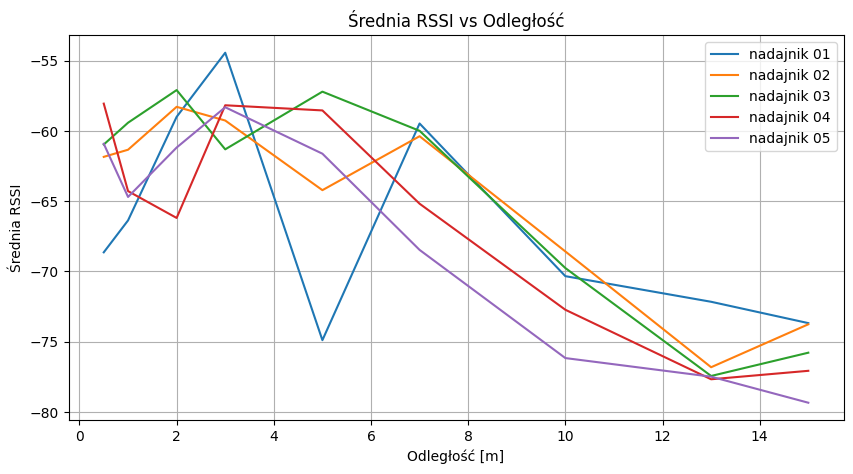

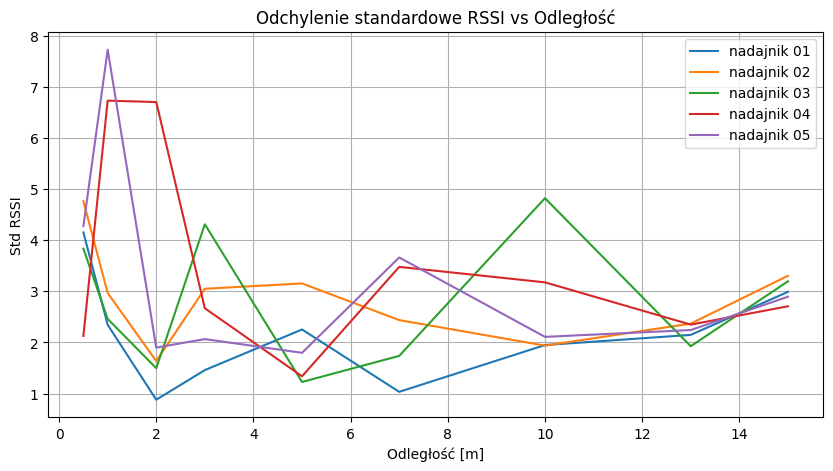

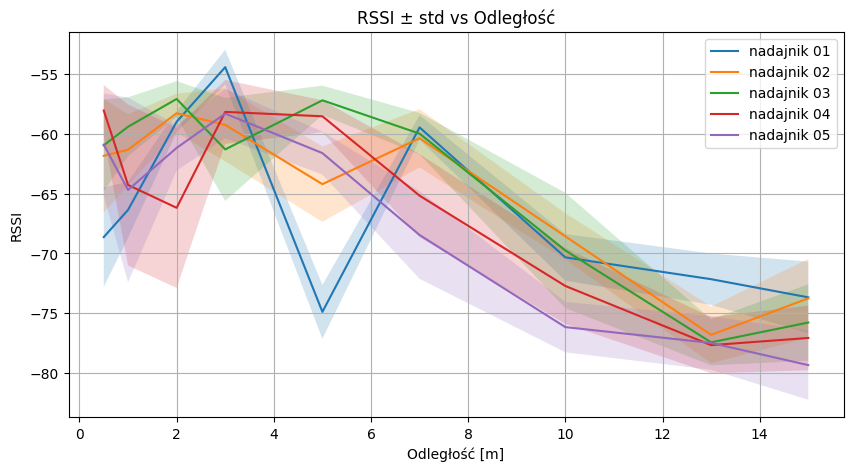

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
plt.title('Średnia RSSI vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('Średnia RSSI')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['std'], label=f'nadajnik {nadajnik}')
plt.title('Odchylenie standardowe RSSI vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('Std RSSI')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
    plt.fill_between(data['distance'], data['mean'] - data['std'], data['mean'] + data['std'], alpha=0.2)
plt.title('RSSI ± std vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('RSSI')
plt.legend()
plt.grid(True)
plt.show()

# 2 pomiar

## Dane

In [ ]:
import pandas as pd
import os
import csv
from io import StringIO

path = os.path.join("/home","korius","Documents", "Magisterka", "Pomiary","Sygnaly","18.09.2025_09")
head = "Date,id,Tx_p,rssi\n"

with open(os.path.join(path, "0.5m_200.txt"), "r") as f:
    content = f.read()
    d05m = pd.read_csv(StringIO(head+content))
   
with open(os.path.join(path, "1.0m_200.txt"), "r") as f:
    content = f.read()
    d1m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "2.0m_200.txt"), "r") as f:
    content = f.read()
    d2m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "3.0m_200.txt"), "r") as f:
    content = f.read()
    d3m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "5.0m_200.txt"), "r") as f:
    content = f.read()
    d5m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "7.0m_200.txt"), "r") as f:
    content = f.read()
    d7m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "10.0m_200.txt"), "r") as f:
    content = f.read()
    d10m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "13.0m_200.txt"), "r") as f:
    content = f.read()
    d13m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "15.0m_200.txt"), "r") as f:
    content = f.read()
    d15m = pd.read_csv(StringIO(head+content))

to_time(d05m)
to_time(d1m)
to_time(d2m)
to_time(d3m)
to_time(d5m)
to_time(d7m)
to_time(d10m)
to_time(d13m)
to_time(d15m)

In [ ]:
dataframes = {
    0.5: d05m,
    1:   d1m,
    2:   d2m,
    3:   d3m,
    5:   d5m,
    7:   d7m,
    10:  d10m,
    13:  d13m,
    15:  d15m,
}

In [ ]:
dataframes

{0.5:                            Date                  id  Tx_p  rssi        ms
 0    2025-09-18 11:52:25.908447   07:00:00:00:00:00    -3   -58  42745908
 1    2025-09-18 11:52:25.922190   06:00:00:00:00:00    -4   -52  42745922
 2    2025-09-18 11:52:25.957942   09:00:00:00:00:00    -1   -64  42745957
 3    2025-09-18 11:52:26.101358   08:00:00:00:00:00    -2   -67  42746101
 4    2025-09-18 11:52:26.264652   09:00:00:00:00:00    -1   -63  42746264
 ...                         ...                 ...   ...   ...       ...
 2220 2025-09-18 11:55:45.347500   08:00:00:00:00:00    -2   -62  42945347
 2221 2025-09-18 11:55:45.472881   09:00:00:00:00:00    -1   -60  42945472
 2222 2025-09-18 11:55:45.619755   07:00:00:00:00:00    -3   -53  42945619
 2223 2025-09-18 11:55:45.656457   08:00:00:00:00:00    -2   -62  42945656
 2224 2025-09-18 11:55:45.776180   09:00:00:00:00:00    -1   -59  42945776
 
 [2225 rows x 5 columns],
 1:                            Date                  id  Tx_p  rssi

In [ ]:
summary = []

for dist, df in dataframes.items():
    grouped = df.groupby('id')['rssi'].agg(['mean', 'std']).reset_index()
    grouped['distance'] = dist
    summary.append(grouped)

summary_df = pd.concat(summary)
summary_df['nadajnik'] = summary_df['id'].str.split(':').str[0]
# summary_df['distance'] = summary_df['distance'].str.replace('m', '').astype(float)
summary_df = summary_df.sort_values(by='distance')

In [ ]:
summary_df

,id,mean,std,distance,nadajnik
0,00:00:00:00:00:01,-63.903614,2.118401,0.5,00
1,06:00:00:00:00:00,-56.671756,2.571926,0.5,06
2,07:00:00:00:00:00,-55.482490,1.363934,0.5,07
3,08:00:00:00:00:00,-65.718563,5.662388,0.5,08
4,09:00:00:00:00:00,-61.146154,3.452092,0.5,09
0,00:00:00:00:00:01,-67.911765,2.664334,1.0,00
1,06:00:00:00:00:00,-61.070896,2.018284,1.0,06
2,07:00:00:00:00:00,-56.843985,2.590018,1.0,07
3,08:00:00:00:00:00,-55.873321,4.444452,1.0,08
4,09:00:00:00:00:00,-57.558879,5.013072,1.0,09


In [ ]:
print(f"0.5 m: {len(d05m)} | 1 m: {len(d1m)} | 2 m: {len(d2m)} | 3 m: {len(d3m)} | 5 m: {len(d5m)} |\n  7 m: {len(d7m)} | 10 m: {len(d10m)} | 13 m: {len(d13m)} | 15 m: {len(d15m)}")

0.5 m: 2225 | 1 m: 2294 | 2 m: 2170 | 3 m: 2274 | 5 m: 2161 |
  7 m: 2243 | 10 m: 2306 | 13 m: 2361 | 15 m: 2339


In [ ]:
print(d2m["id"].value_counts())

id
07:00:00:00:00:00    532
08:00:00:00:00:00    526
06:00:00:00:00:00    515
09:00:00:00:00:00    445
00:00:00:00:00:01    152
Name: count, dtype: int64


In [ ]:
n09_2m = d2m[d2m["id"]==" 09:00:00:00:00:00"]

In [ ]:
n09_2m.head(20)

,Date,id,Tx_p,rssi,ms
3,2025-09-18 12:04:10.671260,09:00:00:00:00:00,-1,-72,43450671
6,2025-09-18 12:04:10.970821,09:00:00:00:00:00,-1,-72,43450970
11,2025-09-18 12:04:11.275553,09:00:00:00:00:00,-1,-69,43451275
16,2025-09-18 12:04:11.581180,09:00:00:00:00:00,-1,-71,43451581
19,2025-09-18 12:04:11.882789,09:00:00:00:00:00,-1,-70,43451882
22,2025-09-18 12:04:12.182742,09:00:00:00:00:00,-1,-55,43452182
25,2025-09-18 12:04:12.482760,09:00:00:00:00:00,-1,-54,43452482
32,2025-09-18 12:04:13.083811,09:00:00:00:00:00,-1,-52,43453083
34,2025-09-18 12:04:13.384153,09:00:00:00:00:00,-1,-51,43453384
45,2025-09-18 12:04:14.290219,09:00:00:00:00:00,-1,-51,43454290


In [ ]:
print(d5m["id"].value_counts())

id
06:00:00:00:00:00    522
09:00:00:00:00:00    514
07:00:00:00:00:00    505
08:00:00:00:00:00    496
00:00:00:00:00:01    124
Name: count, dtype: int64


In [ ]:
n01_5m = d5m[d5m["id"]==" 00:00:00:00:00:01"]

In [ ]:
n01_5m.head(20)

,Date,id,Tx_p,rssi,ms
7,2025-09-18 12:19:48.788596,00:00:00:00:00:01,-5,-71,44388788
33,2025-09-18 12:19:51.461478,00:00:00:00:00:01,-5,-72,44391461
38,2025-09-18 12:19:51.760587,00:00:00:00:00:01,-5,-70,44391760
47,2025-09-18 12:19:52.365442,00:00:00:00:00:01,-5,-75,44392365
78,2025-09-18 12:19:55.376073,00:00:00:00:00:01,-5,-72,44395376
128,2025-09-18 12:20:00.191900,00:00:00:00:00:01,-5,-70,44400191
133,2025-09-18 12:20:00.494117,00:00:00:00:00:01,-5,-69,44400494
141,2025-09-18 12:20:01.406441,00:00:00:00:00:01,-5,-69,44401406
154,2025-09-18 12:20:02.621729,00:00:00:00:00:01,-5,-69,44402621
226,2025-09-18 12:20:09.550510,00:00:00:00:00:01,-5,-71,44409550


## Wykresy

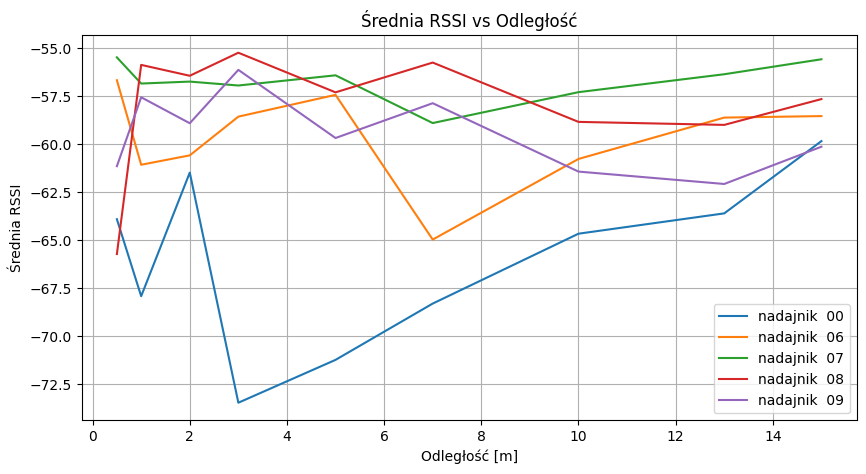

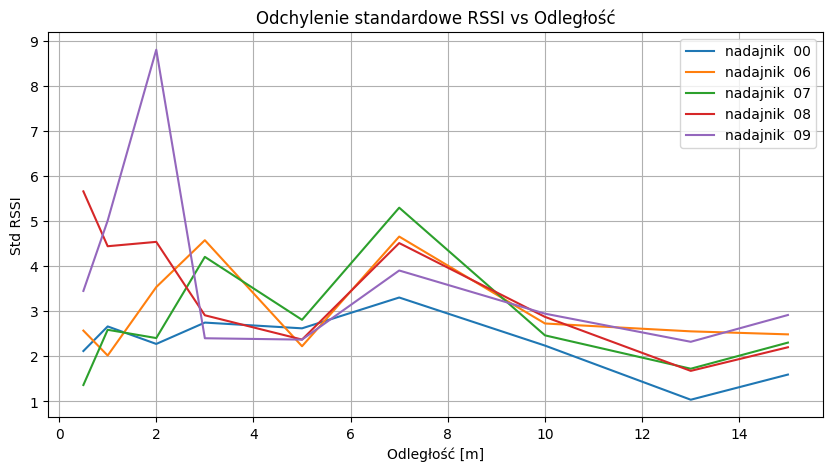

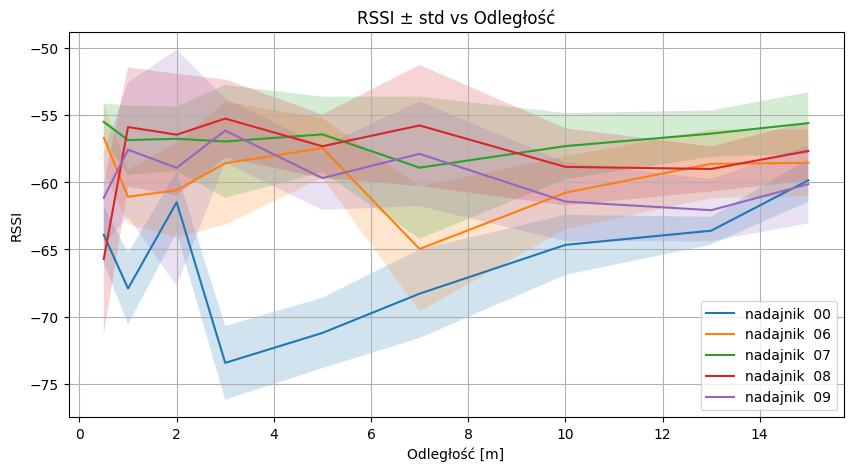

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
plt.title('Średnia RSSI vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('Średnia RSSI')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['std'], label=f'nadajnik {nadajnik}')
plt.title('Odchylenie standardowe RSSI vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('Std RSSI')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
    plt.fill_between(data['distance'], data['mean'] - data['std'], data['mean'] + data['std'], alpha=0.2)
plt.title('RSSI ± std vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('RSSI')
plt.legend()
plt.grid(True)
plt.show()

# 3 pomiar

## Dane

In [6]:
import pandas as pd
import os
import csv
from io import StringIO

path = os.path.join("..", "data", "18.09.2025_10")
head = "Date,id,Tx_p,rssi\n"

with open(os.path.join(path, "0.5m_100.txt"), "r") as f:
    content = f.read()
    d05m = pd.read_csv(StringIO(head+content))
   
with open(os.path.join(path, "1.0m_100.txt"), "r") as f:
    content = f.read()
    d1m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "2.0m_100.txt"), "r") as f:
    content = f.read()
    d2m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "3.0m_100.txt"), "r") as f:
    content = f.read()
    d3m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "5.0m_100.txt"), "r") as f:
    content = f.read()
    d5m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "7.0m_100.txt"), "r") as f:
    content = f.read()
    d7m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "10.0m_100.txt"), "r") as f:
    content = f.read()
    d10m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "13.0m_100.txt"), "r") as f:
    content = f.read()
    d13m = pd.read_csv(StringIO(head+content))

with open(os.path.join(path, "15.0m_100.txt"), "r") as f:
    content = f.read()
    d15m = pd.read_csv(StringIO(head+content))


In [7]:
dataframes = {
    0.5: d05m,
    1:   d1m,
    2:   d2m,
    3:   d3m,
    5:   d5m,
    7:   d7m,
    10:  d10m,
    13:  d13m,
    15:  d15m,
}

In [9]:
dataframes

{0.5:                             Date                  id  Tx_p  rssi
 0     2025-09-18 15:28:16.547292   07:00:00:00:00:00    -3   -54
 1     2025-09-18 15:28:16.583316   08:00:00:00:00:00    -2   -61
 2     2025-09-18 15:28:16.590887   09:00:00:00:00:00    -1   -62
 3     2025-09-18 15:28:16.757583   06:00:00:00:00:00    -4   -58
 4     2025-09-18 15:28:16.849221   07:00:00:00:00:00    -3   -53
 ...                          ...                 ...   ...   ...
 1189  2025-09-18 15:29:56.074731   00:00:00:00:00:01    -5   -57
 1190  2025-09-18 15:29:56.247137   08:00:00:00:00:00    -2   -57
 1191  2025-09-18 15:29:56.296370   09:00:00:00:00:00    -1   -58
 1192  2025-09-18 15:29:56.306808   07:00:00:00:00:00    -3   -57
 1193  2025-09-18 15:29:56.375523   00:00:00:00:00:01    -5   -55
 
 [1194 rows x 4 columns],
 1:                             Date                  id  Tx_p  rssi
 0     2025-09-18 15:31:37.441684   06:00:00:00:00:00    -4   -53
 1     2025-09-18 15:31:37.585566   08:0

In [10]:
summary = []

for dist, df in dataframes.items():
    grouped = df.groupby('id')['rssi'].agg(['mean', 'std']).reset_index()
    grouped['distance'] = dist
    summary.append(grouped)

summary_df = pd.concat(summary)
summary_df['nadajnik'] = summary_df['id'].str.split(':').str[0]
# summary_df['distance'] = summary_df['distance'].str.replace('m', '').astype(float)
summary_df = summary_df.sort_values(by='distance')

In [11]:
summary_df

,id,mean,std,distance,nadajnik
0,00:00:00:00:00:01,-54.929412,1.325467,0.5,00
1,06:00:00:00:00:00,-58.108696,1.643432,0.5,06
2,07:00:00:00:00:00,-59.996324,5.642811,0.5,07
3,08:00:00:00:00:00,-60.354386,4.890781,0.5,08
4,09:00:00:00:00:00,-57.862319,5.015890,0.5,09
0,00:00:00:00:00:01,-56.840426,1.264088,1.0,00
1,06:00:00:00:00:00,-57.090909,2.288281,1.0,06
2,07:00:00:00:00:00,-53.947552,2.393129,1.0,07
3,08:00:00:00:00:00,-55.208904,2.760956,1.0,08
4,09:00:00:00:00:00,-61.608059,5.314749,1.0,09


In [12]:
print(f"0.5 m: {len(d05m)} | 1 m: {len(d1m)} | 2 m: {len(d2m)} | 3 m: {len(d3m)} | 5 m: {len(d5m)} |\n  7 m: {len(d7m)} | 10 m: {len(d10m)} | 13 m: {len(d13m)} | 15 m: {len(d15m)}")

0.5 m: 1194 | 1 m: 1220 | 2 m: 1198 | 3 m: 1166 | 5 m: 1206 |
  7 m: 995 | 10 m: 1173 | 13 m: 726 | 15 m: 1146


In [13]:
print(d2m["id"].value_counts())

id
07:00:00:00:00:00    291
09:00:00:00:00:00    280
06:00:00:00:00:00    271
08:00:00:00:00:00    259
00:00:00:00:00:01     97
Name: count, dtype: int64


In [14]:
n09_2m = d2m[d2m["id"]==" 09:00:00:00:00:00"]

In [15]:
n09_2m.head(20)

,Date,id,Tx_p,rssi
2,2025-09-18 15:39:15.005485,09:00:00:00:00:00,-1,-62
6,2025-09-18 15:39:15.311472,09:00:00:00:00:00,-1,-57
10,2025-09-18 15:39:15.619732,09:00:00:00:00:00,-1,-66
14,2025-09-18 15:39:15.921350,09:00:00:00:00:00,-1,-62
18,2025-09-18 15:39:16.224217,09:00:00:00:00:00,-1,-67
22,2025-09-18 15:39:16.528651,09:00:00:00:00:00,-1,-56
26,2025-09-18 15:39:16.835588,09:00:00:00:00:00,-1,-59
30,2025-09-18 15:39:17.137765,09:00:00:00:00:00,-1,-59
34,2025-09-18 15:39:17.439772,09:00:00:00:00:00,-1,-63
37,2025-09-18 15:39:17.737261,09:00:00:00:00:00,-1,-60


In [16]:
print(d5m["id"].value_counts())

id
07:00:00:00:00:00    286
08:00:00:00:00:00    282
09:00:00:00:00:00    280
06:00:00:00:00:00    277
00:00:00:00:00:01     81
Name: count, dtype: int64


In [17]:
n01_5m = d5m[d5m["id"]==" 00:00:00:00:00:01"]

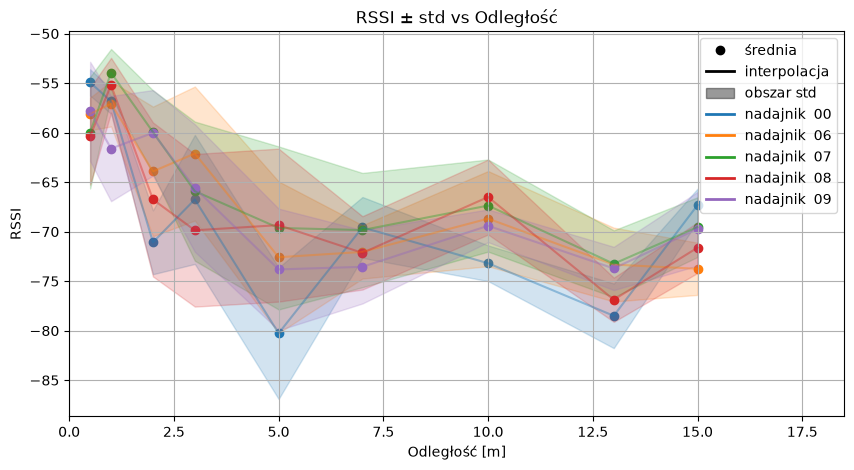

In [35]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.figure(figsize=(10, 5))
colors = plt.cm.tab10.colors
legend_handles = []
legend_labels = []

for idx, nadajnik in enumerate(summary_df['nadajnik'].unique()):
    color = colors[idx % len(colors)]
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['mean'], color=color, alpha=0.4)
    plt.scatter(data['distance'], data['mean'], color=color)
    plt.fill_between(data['distance'], data['mean'] - data['std'], data['mean'] + data['std'], color=color, alpha=0.2)
    legend_handles.append(Line2D([0], [0], color=color, lw=2))
    legend_labels.append(f'nadajnik {nadajnik}')

avg_handle = Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=6)
interp_handle = Line2D([0], [0], color='black', lw=2)
area_handle = Patch(facecolor='black', alpha=0.4, edgecolor='black')

plt.title('RSSI ± std vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('RSSI')
plt.legend(handles=[avg_handle, interp_handle, area_handle] + legend_handles,
           labels=['średnia', 'interpolacja', 'obszar std'] + legend_labels,
           ncol=1,
           frameon=True)

plt.xlim(0, 18.5)
plt.grid(True)
plt.show()

## Wykresy

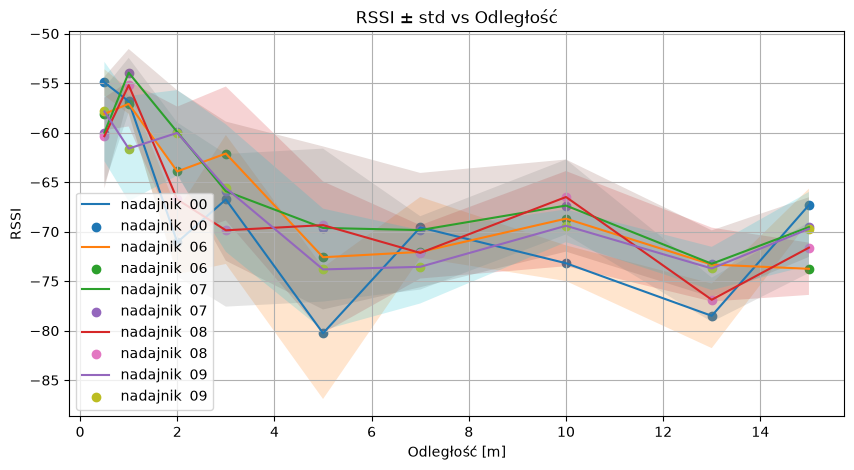

In [21]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# for nadajnik in summary_df['nadajnik'].unique():
#     data = summary_df[summary_df['nadajnik'] == nadajnik]
#     plt.plot(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
# plt.title('Średnia RSSI vs Odległość')
# plt.xlabel('Odległość [m]')
# plt.ylabel('Średnia RSSI')
# plt.legend()
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(10, 5))
# for nadajnik in summary_df['nadajnik'].unique():
#     data = summary_df[summary_df['nadajnik'] == nadajnik]
#     plt.plot(data['distance'], data['std'], label=f'nadajnik {nadajnik}')
# plt.title('Odchylenie standardowe RSSI vs Odległość')
# plt.xlabel('Odległość [m]')
# plt.ylabel('Std RSSI')
# plt.legend()
# plt.grid(True)
# plt.show()

plt.figure(figsize=(10, 5))
for nadajnik in summary_df['nadajnik'].unique():
    data = summary_df[summary_df['nadajnik'] == nadajnik]
    plt.plot(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
    plt.scatter(data['distance'], data['mean'], label=f'nadajnik {nadajnik}')
    plt.fill_between(data['distance'], data['mean'] - data['std'], data['mean'] + data['std'], alpha=0.2)
plt.title('RSSI ± std vs Odległość')
plt.xlabel('Odległość [m]')
plt.ylabel('RSSI')
plt.legend()
plt.grid(True)
plt.show()